In [1]:
# Run this in the first cell of your Colab notebook
!pip install umap-learn datasets transformers evaluate

Notes: 

* Simple natural language model DistilBERT is used (simpler version of BERT (transformers))

* We ignore inputs "keyword" and "location", making the model text-only.

* It works :)

In [3]:
import pandas as pd
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    AutoModel,
    TrainingArguments,
    Trainer,
)
import evaluate
import numpy as np
import matplotlib.pyplot as plt
import umap.umap_ as umap
from torch.utils.data import DataLoader
from matplotlib.lines import Line2D

# 1. LOAD THE DATA
df = pd.read_csv('train.csv')
df = df[['text', 'target']]  # Keep only what we need
df = df.dropna()             # Remove empty rows

# Rename 'target' to 'label' because HuggingFace Trainer expects 'label'
df = df.rename(columns={'target': 'label'})

# Convert pandas dataframe to Hugging Face Dataset format
hf_dataset = Dataset.from_pandas(df)

# Split into 80% training and 20% testing
hf_dataset = hf_dataset.train_test_split(test_size=0.2)

# 2. TOKENIZER (Text to Numbers)
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    # padding="max_length" makes all sentences the same length by adding zeros
    # truncation=True cuts off sentences that are too long
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=128,
    )

# Apply the tokenizer to our entire dataset
tokenized_datasets = hf_dataset.map(tokenize_function, batched=True)

# 3. MODEL (Binary Classification)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
)

# 4. METRIC
metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

# 5. TRAINING SETUP
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",  # <- correct argument name
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=50,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)

# 6. TRAIN
print("Starting training...")
trainer.train()
print("Training complete.")


Map:   0%|          | 0/6090 [00:00<?, ? examples/s]

Map:   0%|          | 0/1523 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting training...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.418719,0.375612,0.845043
2,0.290972,0.386199,0.855548
3,0.264401,0.419064,0.851609


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training complete.


## Build encoder and prepare dataloader

In [4]:
# 7. BUILD ENCODER (base DistilBERT without classification head)
# We want the encoder weights from the fine-tuned classifier model

encoder = AutoModel.from_pretrained(model_name)
# Copy the base encoder weights from the fine-tuned classification model
encoder.load_state_dict(model.base_model.state_dict())
encoder.to(model.device)
encoder.eval()

# 8. PREPARE TEST SET FOR PYTORCH
test_ds = tokenized_datasets["test"]

# If test set is very large, you can subsample (e.g., first 2000 examples)
# test_ds = test_ds.shuffle(seed=42).select(range(2000))

# HuggingFace Dataset -> PyTorch Tensors
test_ds = test_ds.remove_columns([col for col in test_ds.column_names
                                  if col not in ["input_ids", "attention_mask", "label"]])

test_ds.set_format(type="torch")

test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
len(test_ds), next(iter(test_loader))["input_ids"].shape


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(1523, torch.Size([64, 128]))

## Extract embeddings for each tweet

In [5]:
# 9. EXTRACT EMBEDDINGS
all_embeddings = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(model.device)
        attention_mask = batch["attention_mask"].to(model.device)
        labels = batch["label"].cpu().numpy()

        # Get hidden states from encoder
        outputs = encoder(input_ids=input_ids, attention_mask=attention_mask)
        # outputs.last_hidden_state: [batch_size, seq_len, hidden_dim]
        # Use [CLS]-like embedding at position 0
        cls_embeddings = outputs.last_hidden_state[:, 0, :]  # [batch, hidden_dim]

        all_embeddings.append(cls_embeddings.cpu().numpy())
        all_labels.append(labels)

embeddings = np.concatenate(all_embeddings, axis=0)
labels = np.concatenate(all_labels, axis=0)

print("Embeddings shape:", embeddings.shape)  # (num_examples, 768)
print("Labels shape:", labels.shape)


Embeddings shape: (1523, 768)
Labels shape: (1523,)


## Run UMAP and plot

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP output shape: (1523, 2)


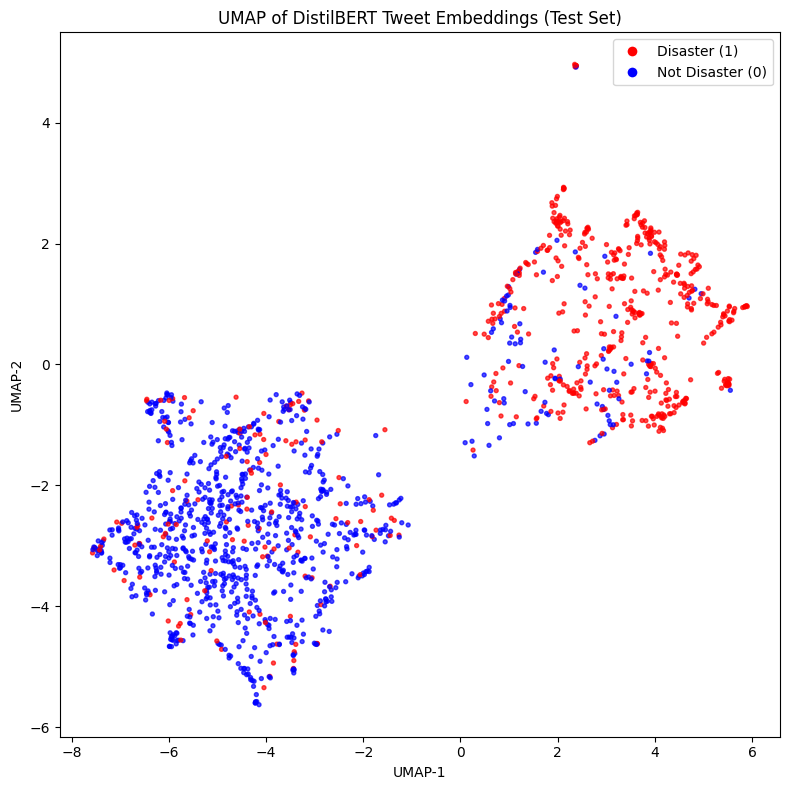

In [6]:
# 10. UMAP REDUCTION
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42,
)

embeddings_2d = reducer.fit_transform(embeddings)
print("UMAP output shape:", embeddings_2d.shape)

# 11. PLOT
plt.figure(figsize=(8, 8))

# Color by label: 1 = disaster (red), 0 = not disaster (blue)
colors = np.where(labels == 1, "red", "blue")

plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1],
    c=colors,
    s=8,
    alpha=0.7,
)

plt.title("UMAP of DistilBERT Tweet Embeddings (Test Set)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Disaster (1)',
           markerfacecolor='red', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Not Disaster (0)',
           markerfacecolor='blue', markersize=8),
]
plt.legend(handles=legend_elements, loc='best')
plt.tight_layout()
plt.show()
